In [23]:
import pandas as pd
import matplotlib.dates as mdates
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from meteostat import Point, Hourly, Stations
from tqdm import tqdm
import sys
import numpy as np
from pathlib import Path
import re
from datetime import datetime

In [24]:
sys.path.append('Utils/')
from PlotUtils import setMplParam, getColour, getHistoParam 
# getHistoParam: 
# Nbins, binwidth, bins, counts, bin_centers  = 
# from ExternalFunctions import nice_string_output, add_text_to_ax
setMplParam()
from DataPipelineWorkShop import get_hourly_example, MeteoPreprocessor

In [25]:
def make_single_window_dataframe(location: Point, 
                                 start_time: datetime, 
                                 horizon_hours: int) -> pd.DataFrame:
    """
    Construct a minimal Meteostat dataframe covering exactly one forecasting window.

    Args:
        location (Point): Meteostat location object.
        start_time (datetime): End of the observation window (the forecast will start right after this).
        exp_ctx (ExperimentContext): Contains forecast.window and forecast.horizon.
    """

    # Fetch data covering just enough history for one forecast
    history_end  = start_time + pd.Timedelta(hours=horizon_hours)

    df = get_hourly_example(location, start_time, history_end)
    df = df[df.index < history_end]

    # Defensive timestamp conversion
    if isinstance(df.index, pd.PeriodIndex):
        df.index = df.index.to_timestamp()

    return df

In [26]:
# kbh = Point(lat=55.6761, lon=12.5683)
# start_time = datetime(2021, 3, 21, 0, 0)
# df_true = make_single_window_dataframe(kbh, start_time, horizon_hours=12)
# df_true.columns
# df_true[['temp', 'rhum', 'prcp', 'wdir', 'wspd']]

## File name pattern (2026.05.19)
```
prediction/20260519/154306/
           └── run_date / run_time from config["date"], config["time"]

20260519_172040_last_20231009_0000(hangeulnal_formid).csv
└──────┘ └────┘ └──┘ └───────────┘ └────────────────┘
 save    save   ckpt  forecast     semantic label
 date    time   tag   start time
 ```

In [27]:
base = Path("/home/cyan_white_tower/projects/MeteoFormer/prediction/")

# before 20260528
# PREDICTION_PATH_PATTERN = re.compile(
#     r"(?P<train_date>\d{8})/"
#     r"(?P<train_time>\d{6})/"
#     r"(?P<prediction_date>\d{8})_"
#     r"(?P<prediction_time>\d{6})_"
#     r"window(?P<prediction_window>\d+)/"
#     r"(?P<save_date>\d{8})_"
#     r"(?P<save_time>\d{6})_"
#     r"(?P<ckpt_tag>.+)_"
#     r"(?P<start_time>\d{8}_\d{4})"
#     r"\((?P<when_key>.+)\)\.csv$"
# )

PREDICTION_PATH_PATTERN = re.compile(
    r"(?P<train_date>\d{8})/"
    r"(?P<train_time>\d{6})/"
    r"(?P<prediction_date>\d{8})_"
    r"(?P<prediction_time>\d{6})_"
    r"(?:window|win)(?P<prediction_window>\d+)"
    r"(?:_hor(?P<prediction_horizon>\d+))?/"
    r"(?P<save_date>\d{8})_"
    r"(?P<save_time>\d{6})_"
    r"(?P<ckpt_tag>.+)_"
    r"(?P<start_time>\d{8}_\d{4})"
    r"\((?P<when_key>.+)\)\.csv$"
)

In [28]:
def parse_prediction_filename(file_path: str | Path, base: Path = base) -> dict:
    file_path = Path(file_path)
    relative_path = file_path.relative_to(base)

    match = PREDICTION_PATH_PATTERN.match(relative_path.as_posix())
    if not match:
        raise ValueError(
            f"Path does not match expected prediction pattern: {relative_path}"
        )

    info = match.groupdict()

    info["path"] = file_path
    info["relative_path"] = relative_path

    info["prediction_window"] = int(info["prediction_window"])

    if info["prediction_horizon"] is not None:
        info["prediction_horizon"] = int(info["prediction_horizon"])
    else:
        info["prediction_horizon"] = None

    info["saved_at"] = datetime.strptime(
        info["save_date"] + info["save_time"],
        "%Y%m%d%H%M%S",
    )

    info["prediction_saved_at"] = datetime.strptime(
        info["prediction_date"] + info["prediction_time"],
        "%Y%m%d%H%M%S",
    )

    info["start_datetime"] = datetime.strptime(
        info["start_time"],
        "%Y%m%d_%H%M",
    )

    ckpt_tag = info["ckpt_tag"]

    if ckpt_tag == "last":
        info["checkpoint_type"] = "last"
        info["epoch"] = None
        info["val_loss"] = None
    else:
        info["checkpoint_type"] = "epoch"

        epoch_match = re.search(r"epoch-(\d+)", ckpt_tag)
        val_loss_match = re.search(r"val_loss-([0-9.]+)", ckpt_tag)

        info["epoch"] = int(epoch_match.group(1)) if epoch_match else None
        info["val_loss"] = float(val_loss_match.group(1)) if val_loss_match else None

    return info

In [29]:
def collect_prediction_files(runs: dict[str, Path]) -> list[dict]:
    rows = []

    for model_name, prediction_run_dir in runs.items():
        for file_path in prediction_run_dir.glob("*.csv"):
            info = parse_prediction_filename(file_path)
            info["model"] = model_name
            rows.append(info)

    return rows

In [30]:
def plot_hourly_features(
    df_true: pd.DataFrame,
    df_pred: pd.DataFrame,
    features: list[str],
    titles: list[str] = None
) -> None:
    # --- normalise time index for df_true ---
    if 'time' in df_true.columns:
        df_true['time'] = pd.to_datetime(df_true['time'])
        df_true = df_true.set_index('time')
    elif isinstance(df_true.index, pd.PeriodIndex):
        df_true.index = df_true.index.to_timestamp()

    # --- normalise time index for df_pred ---
    if 'time' in df_pred.columns:
        df_pred['time'] = pd.to_datetime(df_pred['time'])
        df_pred = df_pred.set_index('time')
    elif isinstance(df_pred.index, pd.PeriodIndex):
        df_pred.index = df_pred.index.to_timestamp()

    n_features = len(features)
    fig, axes = plt.subplots(n_features, 1, figsize=(19, 5*n_features), sharex=True)
    if n_features == 1:
        axes = [axes]
        
    for i, ax, feature in zip(range(n_features), axes, features):
        df_true[feature].plot(ax=ax, label="True")
        df_pred[feature].plot(ax=ax, label="Predicted", color=getColour(i+1))
        ax.set_title(
            titles[i] if titles is not None else feature
        )
        ax.set_ylabel(feature)
        ax.legend()

    axes[-1].set_xlabel("Date")
    plt.tight_layout()
    plt.show()


# plot_hourly_features(df_true, df_pred_inv, 
#                      features=['temp', 'rhum', 'wspd', 'wdir'], 
#                      titles=['Temperature (°C)', 'Relative Humidity (%)', 'Wind Speed (km/h)', 'Wind Direction (°)'])

In [31]:
def compare_models_per_feature(
    prediction_files: dict[str, str],
    features: list[str] = ['temp', 'rhum', 'wspd', 'wdir'],
    titles: list[str] = None,
    horizon_hours: int = 12,
    location: tuple[float, float] = (55.6761, 12.5683),
    start_time: datetime = datetime(2023, 1, 1, 0, 0),
):

    # ------------------------------------------------------------
    # Load TRUE data
    # ------------------------------------------------------------
    lat, lon = location
    kbh = Point(lat=lat, lon=lon)
    df_true = make_single_window_dataframe(kbh, start_time, horizon_hours=horizon_hours)

    if "time" in df_true.columns:
        df_true["time"] = pd.to_datetime(df_true["time"])
        df_true = df_true.set_index("time")

    # ------------------------------------------------------------
    # Load MODEL predictions
    # ------------------------------------------------------------
    preds = {}
    for model_name, file_path in prediction_files.items():
        df_pred = pd.read_csv(file_path)

        if "time" in df_pred.columns:
            df_pred["time"] = pd.to_datetime(df_pred["time"])
            df_pred = df_pred.set_index("time")

        preds[model_name] = df_pred

    # ------------------------------------------------------------
    # Plot features
    # ------------------------------------------------------------
    for idx, feature in enumerate(features):

        # ==========================
        # SPECIAL CASE: WIND DIR
        # ==========================
        if feature == "wdir":
            times = df_true.index
            n_steps = len(times)

            # use integer positions for x (0,1,2,...) to avoid datetime scaling hell
            x_idx = np.arange(n_steps)

            num_models = len(preds) + 1  # True + models
            row_positions = np.arange(num_models)

            fig, ax = plt.subplots(figsize=(18, 4 + num_models * 1.0))

            def plot_direction_row(y, angles_deg, speeds, color, label=None):
                angles = np.deg2rad(angles_deg)

                # normalise windspeed to 0–1
                if speeds.max() > 0:
                    speeds_norm = speeds / speeds.max()
                else:
                    speeds_norm = speeds

                L_max = 0.6   # max arrow length in data coords

                for xi, ang, sn in zip(x_idx, angles, speeds_norm):
                    L = 0.1 + sn * L_max      # optional: small constant base (0.1)
                    dx = L * np.cos(ang)
                    dy = L * np.sin(ang)

                    arrow = FancyArrowPatch(
                        (xi, y),
                        (xi + dx, y + dy),
                        arrowstyle="-|>",
                        mutation_scale=15,
                        lw=1.3,
                        color=color
                    )
                    ax.add_patch(arrow)

                if label:
                    ax.plot([], [], color=color, label=label)

            # True at row 0
            # plot_direction_row(row_positions[0], df_true["wdir"].values, "black", "True")
            plot_direction_row(
                row_positions[0],
                df_true["wdir"].values,
                df_true["wspd"].values,
                "black",
                "True"
            )

            # Models at rows 1, 2, ...
            for i, (model_name, df_pred) in enumerate(preds.items(), start=1):
                # plot_direction_row(row_positions[i], df_pred["wdir"].values, getColour(i-1), model_name)
                plot_direction_row(
                    row_positions[i],
                    df_pred["wdir"].values,
                    df_pred["wspd"].values,
                    getColour(i-1),
                    model_name
                )

            # y-axis labels = True + model names
            ax.set_ylim(-1, num_models)
            ax.set_yticks(row_positions)
            ax.set_yticklabels(["True"] + list(preds.keys()))

            # x-axis: show times as tick labels
            ax.set_xticks(x_idx)
            ax.set_xticklabels(
                [t.strftime("%Y-%m-%d %H:%M") for t in times],
                rotation=45,
                ha="right"
            )

            ax.set_title("Wind Direction (Arrow Timeline)")
            ax.set_xlabel("Time")
            ax.grid(axis="x", linestyle="--", alpha=0.3)
            ax.invert_yaxis()

            plt.tight_layout()
            plt.show()

        # ==========================
        # NORMAL LINE PLOTS
        # ==========================
        fig, ax = plt.subplots(figsize=(18, 6))

        df_true[feature].plot(ax=ax, label="True", linewidth=2, color="black")
        for i, (model_name, df_pred) in enumerate(preds.items()):
            df_pred[feature].plot(ax=ax, label=model_name, color=getColour(i))

        ax.set_title(titles[idx] if titles else feature)
        ax.set_ylabel(feature)
        ax.set_xlabel("Date")
        ax.legend()
        plt.tight_layout()
        plt.show()


In [32]:
# runs_72 = {
#     "vanil_sin_rope_72(72)": base / "20260527" / "114109" / "20260527_143700_window72",
#     "vanil_sin_rope_72(96)": base / "20260527" / "114109" / "20260527_144641_window96",
#     "vanil_sin_rope_72(120)": base / "20260527" / "114109" / "20260527_144958_window120",
#     "vanil_sin_rope_72(48)": base / "20260527" / "114109" / "20260527_145112_window48",
#     "vanil_sin_rope_144(144)": base / "20260527" / "161643" / "20260527_170127_window144",
#     # "vanil_sin_rope_144(72)": base / "20260527" / "161643" / "20260527_181229_window72", # worst, don't use
#     "vanil_sin_rope_144(192)": base / "20260527" / "161643" / "20260527_181539_window192",
#     "vanil_sin_rope_192(192)": base / "20260527" / "192233" / "20260527_200232_window192",
    
# }

runs = {
    "vanil_sin_rope (72-12)": base / "20260527" / "114109" / "20260529_152759_win72_hor12",
    "vanil_sin_rope (72-6)": base / "20260529" / "114520" / "20260529_152944_win72_hor6",
    "vanil_sin_rope (72-3)": base / "20260529" / "124912" / "20260529_153058_win72_hor3",
    }

what_year = 2021

start_times = {
    "new_year_formid" : datetime(what_year, 1, 1, 0, 0),
    "new_year_eftmid" : datetime(what_year, 1, 1, 12, 0),
    "vernal_equinox_formid": datetime(what_year, 3, 21, 0, 0),
    "vernal_equinox_eftmid": datetime(what_year, 3, 21, 12, 0),
    "sankthans_formid": datetime(what_year, 6, 21, 0, 0),
    "sankthans_eftmid": datetime(what_year, 6, 21, 12, 0),
    "hangeulnal_formid": datetime(what_year, 10, 9, 0, 0),
    "hangeulnal_eftmid": datetime(what_year, 10, 9, 12, 0),
}

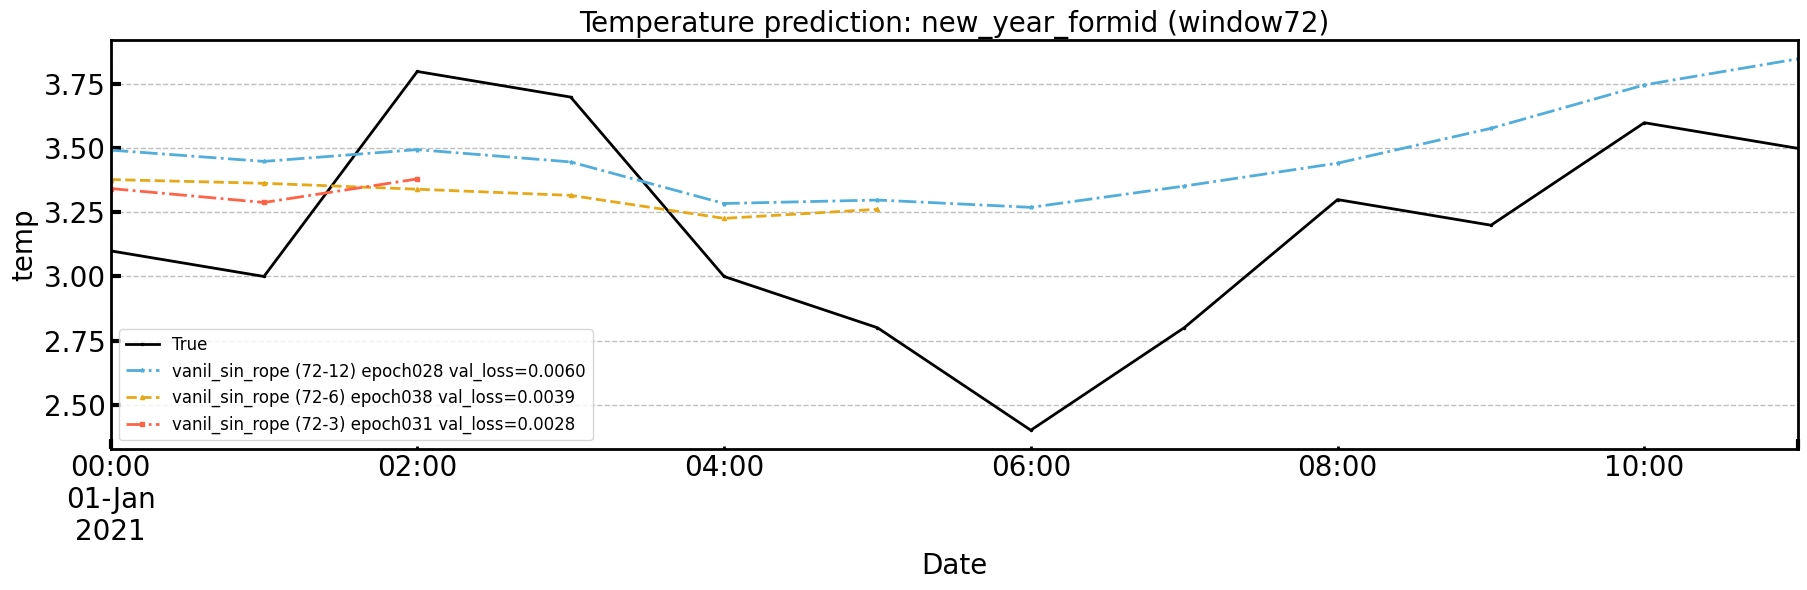

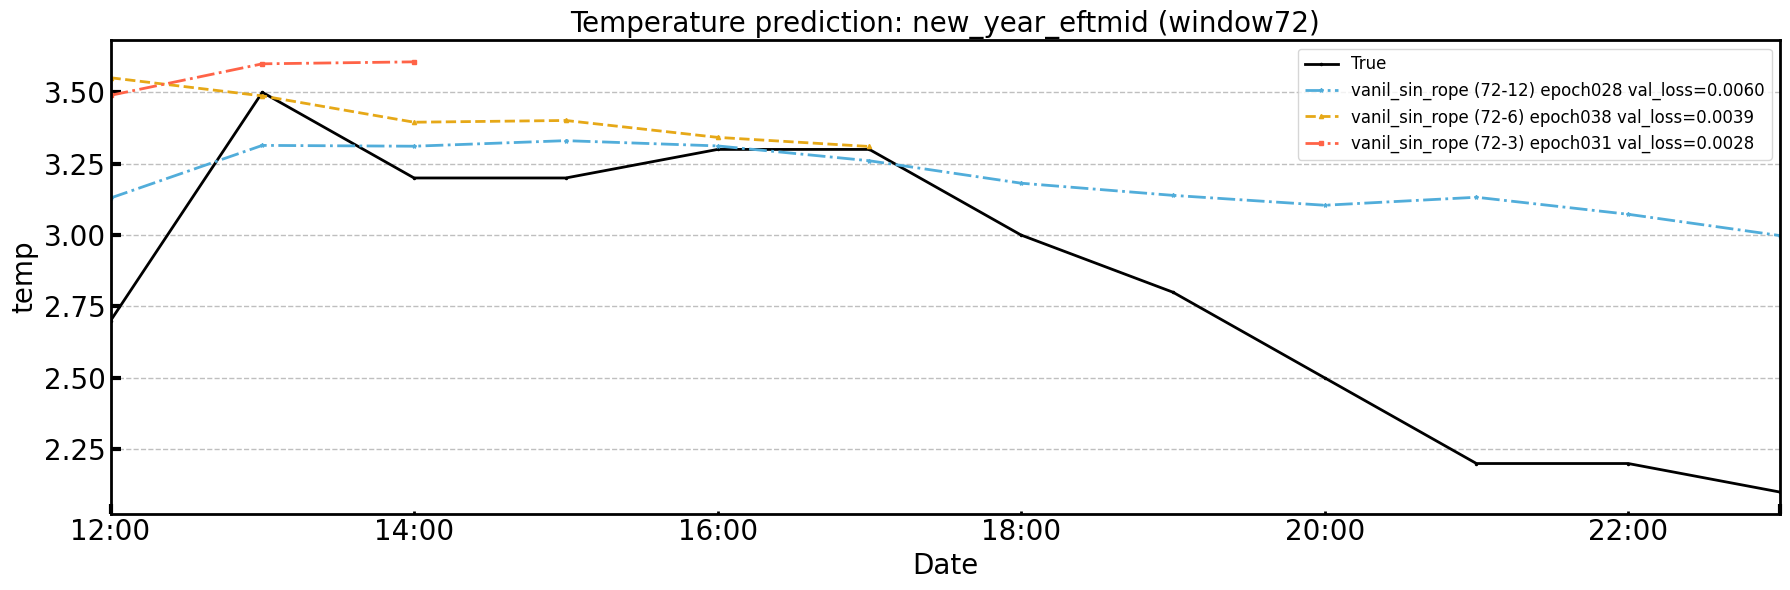

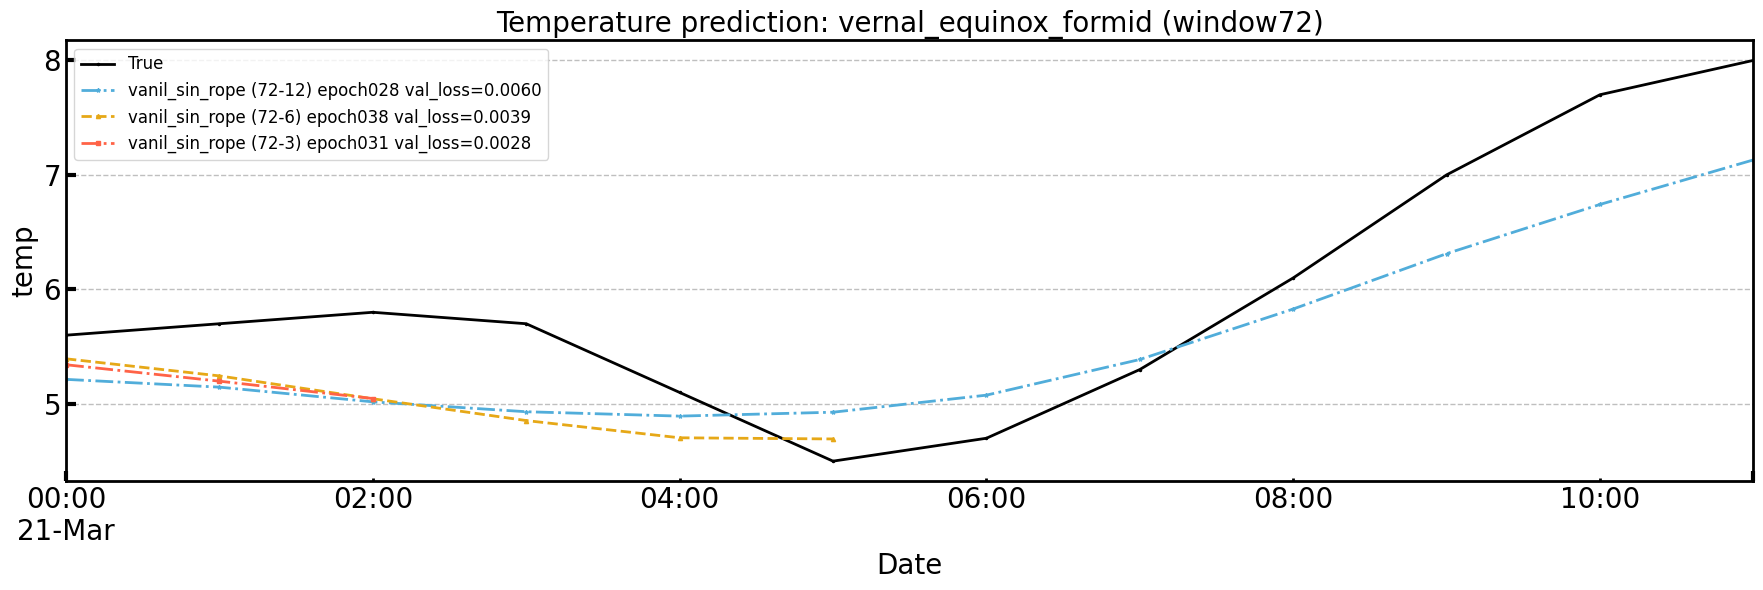

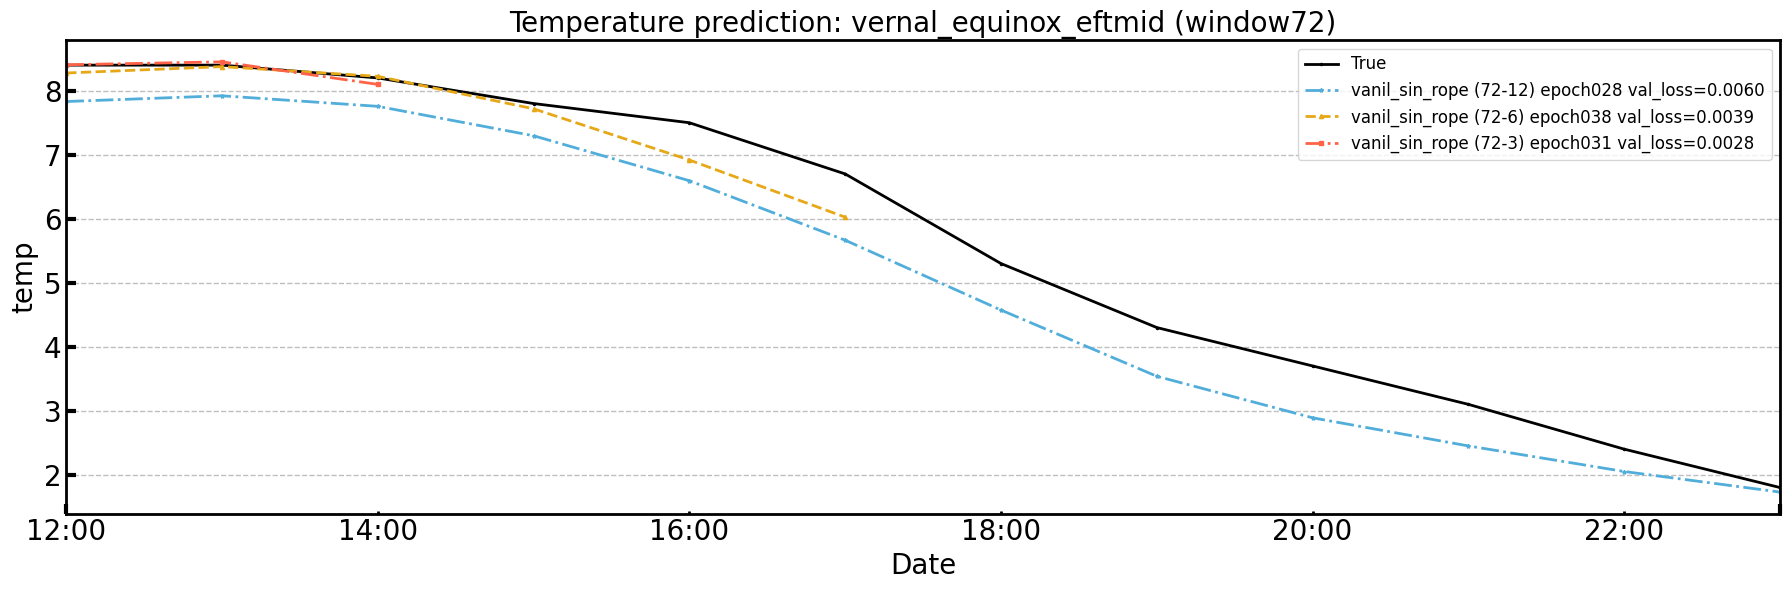

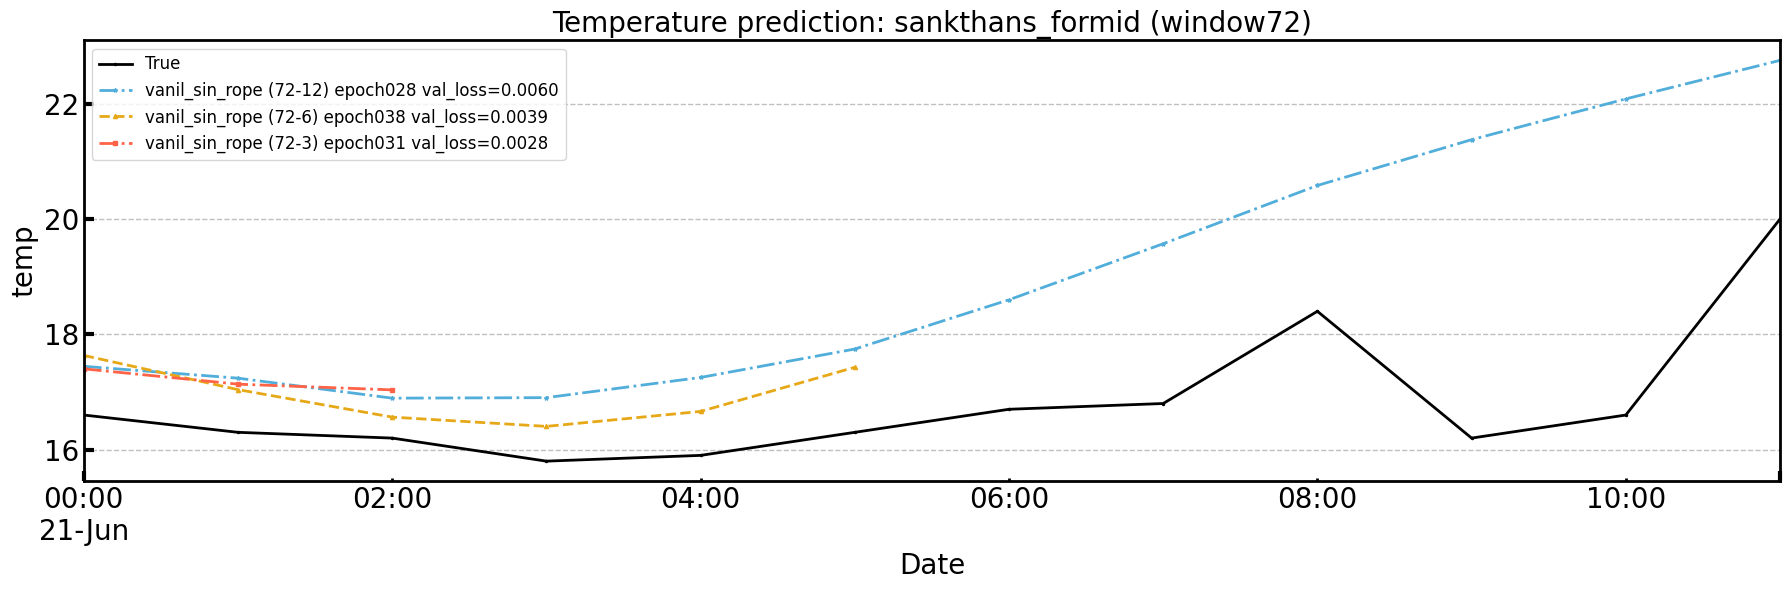

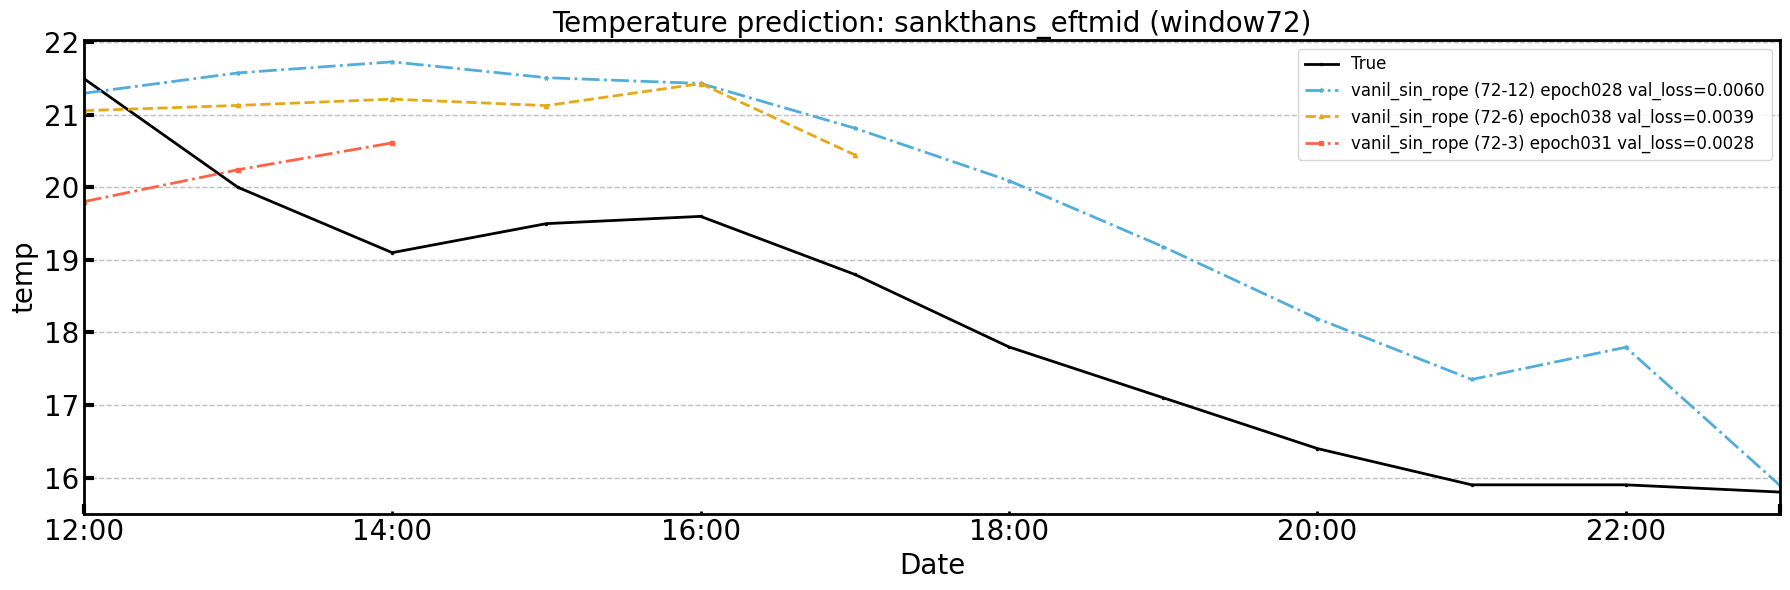

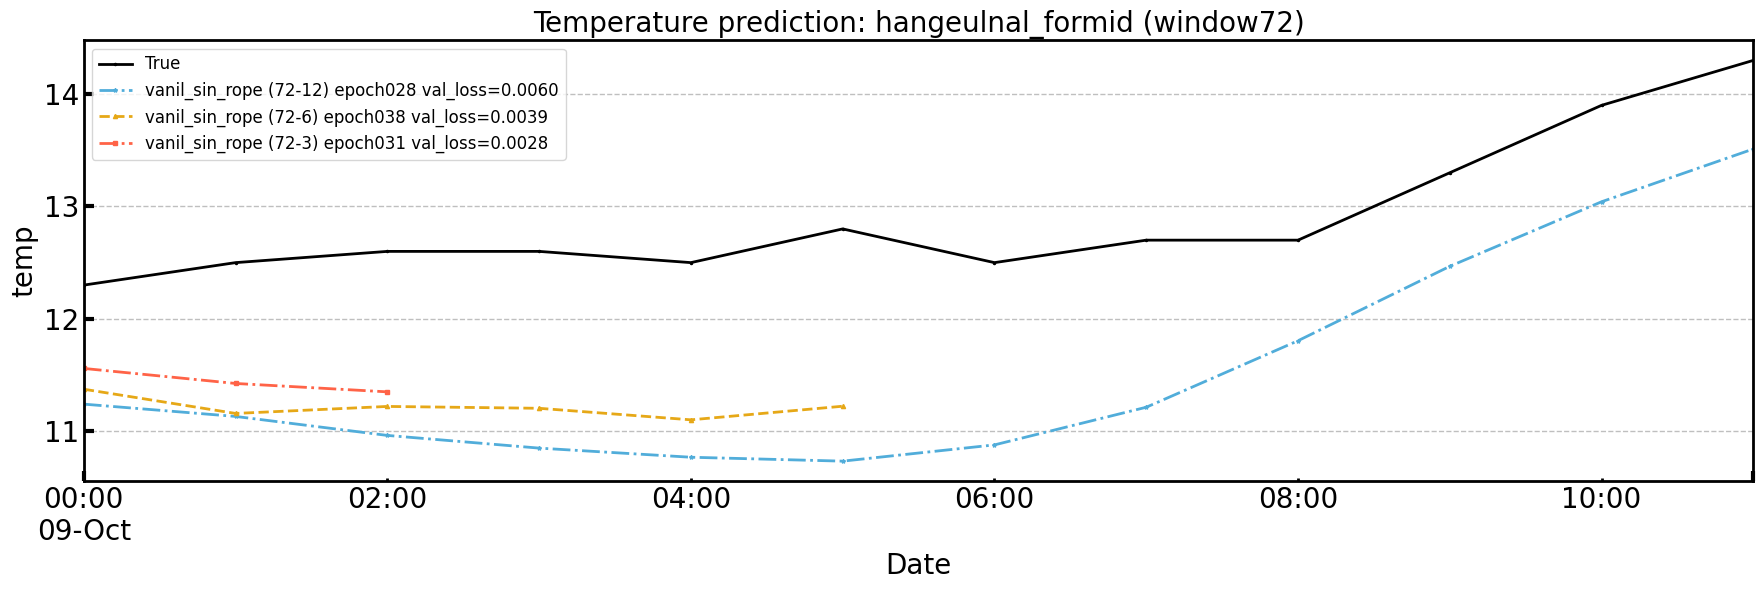

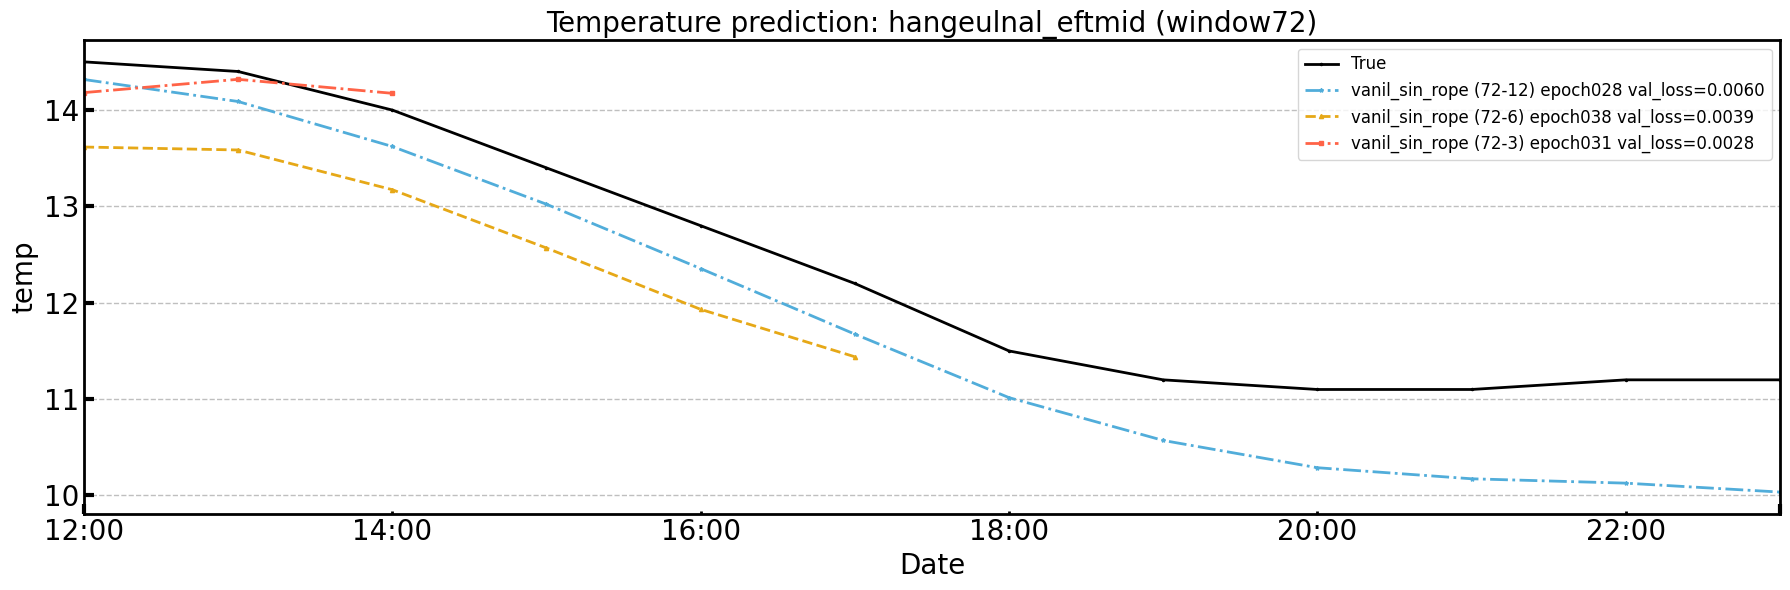

In [33]:
rows = collect_prediction_files(runs)

for when_key, start_time in start_times.items():
    prediction_files = {}
    used_windows = set()

    for row in rows:
        if row["when_key"] != when_key:
            continue

        # temporarily skip last epoch
        if row["checkpoint_type"] == "last":
            continue

        model = row["model"]
        window = row["prediction_window"]
        used_windows.add(window)

        label = (
            f"{model} "
            # f"window{window} "
            f"epoch{row['epoch']:03d} "
            f"val_loss={row['val_loss']:.4f}"
        )

        prediction_files[label] = str(row["path"])

    if not prediction_files:
        print(f"⚠️ No non-last prediction files found for {when_key}")
        continue

    used_windows = sorted(used_windows)

    if len(used_windows) == 1:
        window_text = f"window{used_windows[0]}"
    else:
        window_text = "windows " + ", ".join(str(w) for w in used_windows)

    compare_models_per_feature(
        prediction_files=prediction_files,
        features=["temp"],
        titles=[
            f"Temperature prediction: {when_key} ({window_text})",
        ],
        horizon_hours=12,
        start_time=start_time,
    )